# Seminar 07: Alpha-WGAN

**Date**: 2025/02/18

This notebook presents an implementation of Alpha-GAN using WGAN-GP — a generative model combining ideas from autoencoders and GANs, but with Wasserstein loss and gradient penalty for improved stability.

**Outline:**

- **Setup & Imports:** Installation of dependencies and required imports.
- **Data Preparation:** Loading and preprocessing the CIFAR-10 dataset.
- **Model Architectures:** Definitions for the Encoder, Generator, Discriminator, and Code Discriminator.
- **Utility Functions:** Helper functions for training, logging, and visualization.
- **Training Loop:** A modular training function with diagnostic logging and checkpointing.
- **Evaluation & Visualization:** Generating samples, reconstructions, and exploring latent space interpolation.

## Environment Setup

In [1]:
# Logging
from comet_ml import Experiment
import yaml

with open("cfg.yaml", "r") as f:
    config = yaml.safe_load(f)

experiment = Experiment(
    api_key=config['API_KEY'],
    project_name=config['PROJECT_NAME'],
    workspace=config['WORKSPACE']
)
experiment.set_name("AlphaWGAN Training")
experiment.log_code()

import os
import math

from collections import defaultdict
from itertools import chain
from typing import Any, Dict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import torch.autograd as autograd

from tqdm.auto import tqdm

# Set device
cuda = torch.cuda.is_available()
device = torch.device("cuda" if cuda else ("mps" if torch.backends.mps.is_available() else "cpu"))
torch.backends.cudnn.benchmark = cuda

print(f"Using device: {device}")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/xndrleib/alpha-gan/68d7a7ee5746473793ea9ec995c4b6a5

COMET WARNING: unable to find caller source code in a jupyter notebook; ignoring
/Users/kgb/opt/miniforge3/envs/py311_dgm/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/kgb/opt/miniforge3/envs/py311_dgm/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <CFED5F8E-EC3F-36FD-AAA3-2C6C7F8D3DD9> /Users/kgb/opt/miniforge3/envs/py311_dgm/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <8E6D6BF5-9658-33B9-9D3C-DF587B2F99E7> /Users/kgb/opt/miniforge3/envs/py311_dgm/lib/python3.11/site-packages/torch/lib/libtorch_cpu.dylib'If you don't

Using device: mps


## Data Preparation

We will use the CIFAR-10 dataset. Images are scaled to the range [-1, 1].

In [2]:
# Data Hyperparameters
batch_size = 128
image_size = 16

# Define dataset transformation: convert to tensor and scale pixel values to [-1, 1]
def get_transforms():
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x * 2 - 1)  # Scale from [0, 1] to [-1, 1]
    ])

# Load CIFAR-10 dataset (training and test)
data_dir = '../data'
train_dataset = datasets.CIFAR10(root=data_dir, train=True, transform=get_transforms(), download=True)
test_dataset  = datasets.CIFAR10(root=data_dir, train=False, transform=get_transforms(), download=True)

num_workers = os.cpu_count() if cuda else 0

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=cuda)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=num_workers, pin_memory=cuda)

Files already downloaded and verified
Files already downloaded and verified


## Model Architectures

In Alpha-GAN, we have four main components:

1. **Encoder (E):** Maps an image $x$ to a latent code $z$.
2. **Generator (G):** Maps a latent code $z$ back to an image $x$.
3. **Discriminator (D):** Distinguishes between real images and generated/reconstructed images.
4. **Code Discriminator (C):** Distinguishes between latent codes sampled from the prior and those produced by the encoder.

We also define a helper residual block (`ResBlock`) and two utility layers for reshaping.

In [3]:
# Utility layers for reshaping tensors
class ChannelsToLinear(nn.Linear):
    """Flattens the input and applies a Linear layer."""
    def forward(self, x):
        batch_size = x.size(0)
        return super().forward(x.view(batch_size, -1))

class LinearToChannels2d(nn.Linear):
    """
    Transforms a linear output to a 4D tensor for convolutional layers.
    
    Args:
        in_features (int): Number of input features.
        out_channels (int): Number of output channels.
        w (int): Width of the output spatial dimensions.
        h (int): Height of the output spatial dimensions (defaults to w if None).
    """
    def __init__(self, in_features: int, out_channels: int, w: int = 1, h: int = None, **kwargs: Any):
        h = h or w
        super().__init__(in_features, out_channels * w * h, **kwargs)
        self.w = w
        self.h = h

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        return super().forward(x).view(batch_size, -1, self.w, self.h)

# Residual block used in Encoder and Generator
class ResBlock(nn.Module):
    """
    A simple residual block with two convolutional layers.
    
    Args:
        channels (int): Number of channels in the input/output.
        activation (callable): Activation function constructor.
        norm_layer (callable): Normalization layer constructor.
        groups (int): Number of groups for grouped convolution.
        init_gain (float): Gain factor for Xavier initialization.
    """
    def __init__(self, channels: int, activation=nn.ReLU, norm_layer=nn.BatchNorm2d, groups: int = 1, init_gain: float = 1):
        super().__init__()
        self.activation = activation()
        self.norm1 = norm_layer(channels) if norm_layer else None
        self.norm2 = norm_layer(channels) if norm_layer else None
        
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=(norm_layer is not None), groups=groups)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=(norm_layer is not None), groups=groups)
        
        # Xavier initialization for convolution weights
        nn.init.xavier_normal_(self.conv1.weight, gain=init_gain)
        nn.init.xavier_normal_(self.conv2.weight, gain=init_gain)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        out = self.conv1(x)
        if self.norm1:
            out = self.norm1(out)
        out = self.activation(out)
        out = self.conv2(out)
        if self.norm2:
            out = self.norm2(out)
        return self.activation(out + residual)

### Encoder Network

The encoder downsamples the image through a series of convolutions and residual blocks,
eventually flattening to a latent vector of a specified dimension.

In [4]:
class Encoder(nn.Module):
    """
    Encoder network that maps an image to a latent vector.
    
    Input:
        x (Tensor): Batch of images of shape (N, 3, H, W)
    Output:
        z (Tensor): Batch of latent vectors of shape (N, latent_dim)
    """
    def __init__(self, input_channels: int = 3, base_channels: int = 128, latent_dim: int = 128, img_size: int = 64):
        """
        Args:
            img_size (int): Size of the input image (assumed square). For 64×64 images.
        """
        super().__init__()
        num_pools = 3  # using three AvgPool2d layers
        final_size = img_size // (2 ** num_pools)  # e.g., 64 / 8 = 8
        in_features = base_channels * (final_size ** 2)  # 128 * (8*8) = 8192

        self.net = nn.Sequential(
            nn.Conv2d(input_channels, base_channels, kernel_size=5, stride=1, padding=2),
            nn.AvgPool2d(2),   # 64x64 -> 32x32
            nn.ReLU(),
            ResBlock(base_channels, activation=nn.ReLU, norm_layer=nn.BatchNorm2d),
            nn.AvgPool2d(2),   # 32x32 -> 16x16
            ResBlock(base_channels, activation=nn.ReLU, norm_layer=nn.BatchNorm2d),
            nn.AvgPool2d(2),   # 16x16 -> 8x8
            ResBlock(base_channels, activation=nn.ReLU, norm_layer=nn.BatchNorm2d),
            ChannelsToLinear(in_features, latent_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

### Generator Network

The generator takes a latent vector and produces an image by first mapping the vector to a feature map,
then progressively upsampling with residual blocks.

In [5]:
class Generator(nn.Module):
    def __init__(self, output_channels: int = 3, base_channels: int = 128, 
                 latent_dim: int = 128, img_size: int = 64):
        """
        Args:
            img_size (int): Target image size (assumed square). For 64×64 images.
        """
        super().__init__()
        num_upsamples = 3  # We'll upsample 3 times (2^3 = 8)
        init_size = img_size // (2 ** num_upsamples)  # 64 / 8 = 8
        self.net = nn.Sequential(
            LinearToChannels2d(latent_dim, base_channels, w=init_size, h=init_size),
            nn.ReLU(),
            ResBlock(base_channels, activation=nn.ReLU, norm_layer=nn.BatchNorm2d),
            nn.Upsample(scale_factor=2),  # 8x8 -> 16x16
            ResBlock(base_channels, activation=nn.ReLU, norm_layer=nn.BatchNorm2d),
            nn.Upsample(scale_factor=2),  # 16x16 -> 32x32
            ResBlock(base_channels, activation=nn.ReLU, norm_layer=nn.BatchNorm2d),
            nn.Upsample(scale_factor=2),  # 32x32 -> 64x64
            ResBlock(base_channels, activation=nn.ReLU, norm_layer=nn.BatchNorm2d),
            nn.Conv2d(base_channels, output_channels, kernel_size=1),
            nn.Tanh()  # Output values in [-1, 1]
        )
        
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)

In [6]:
class Generator(nn.Module):
    """
    Generator network that maps a latent vector to an image.
    
    Input:
        z (Tensor): Batch of latent vectors of shape (N, latent_dim)
    Output:
        x (Tensor): Batch of generated images of shape (N, 3, H, W)
    """
    def __init__(self, output_channels: int = 3, base_channels: int = 128, latent_dim: int = 128, img_size: int = 64):
        """
        Args:
            img_size (int): Target image size (assumed square). For 64×64 images.
        """
        super().__init__()

        num_upsamples = 3  # We'll upsample 3 times (2^3 = 8)
        init_size = img_size // (2 ** num_upsamples)  # 64 / 8 = 8
        self.net = nn.Sequential(
            LinearToChannels2d(latent_dim, base_channels, w=init_size, h=init_size),
            nn.ReLU(),

            ResBlock(base_channels, activation=nn.ReLU, norm_layer=nn.BatchNorm2d),
            nn.Upsample(scale_factor=2),  # 8x8 -> 16x16

            ResBlock(base_channels, activation=nn.ReLU, norm_layer=nn.BatchNorm2d),
            nn.Upsample(scale_factor=2),  # 16x16 -> 32x32

            ResBlock(base_channels, activation=nn.ReLU, norm_layer=nn.BatchNorm2d),
            nn.Upsample(scale_factor=2),  # 32x32 -> 64x64

            ResBlock(base_channels, activation=nn.ReLU, norm_layer=nn.BatchNorm2d),
            nn.Conv2d(base_channels, output_channels, kernel_size=1),
            nn.Tanh()  # Output values in [-1, 1]
        )
    
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)

### Discriminator Networks

There are two discriminators:

- **Image Discriminator (D):** Classifies images as real or fake.
- **Code Discriminator (C):** Classifies latent vectors as coming from the prior or the encoder.

In [7]:
class ImageDiscriminator(nn.Module):
    """
    Image Discriminator (Critic) that distinguishes between real and generated images.
    
    Input:
        x (Tensor): Batch of images of shape (N, 3, H, W)
    Output:
        raw scores
    """
    def __init__(self, input_channels: int = 3, base_channels: int = 128, img_size: int = 64):
        super().__init__()
        # Compute final feature map size after three pooling layers
        num_pools = 3  # using three AvgPool2d layers
        final_size = img_size // (2 ** num_pools)  # e.g., 64 / 8 = 8
        in_features = base_channels * (final_size ** 2)  # 128 * (8*8) = 8192

        self.net = nn.Sequential(
            nn.Conv2d(input_channels, base_channels, kernel_size=5, stride=1, padding=2),
            nn.AvgPool2d(2),   # 64x64 -> 32x32
            nn.LeakyReLU(0.2),
            
            ResBlock(base_channels, activation=lambda: nn.LeakyReLU(0.2), norm_layer=nn.BatchNorm2d),
            nn.AvgPool2d(2),   # 32x32 -> 16x16
            
            ResBlock(base_channels, activation=lambda: nn.LeakyReLU(0.2), norm_layer=nn.BatchNorm2d),
            nn.AvgPool2d(2),   # 16x16 -> 8x8
            
            ResBlock(base_channels, activation=lambda: nn.LeakyReLU(0.2), norm_layer=nn.BatchNorm2d),
            ChannelsToLinear(in_features, 1),  # Now in_features=8192
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class CodeDiscriminator(nn.Module):
    """
    Code Discriminator (Critic) that distinguishes between latent codes from the prior and those produced by the encoder.
    
    Input:
        z (Tensor): Batch of latent vectors of shape (N, latent_dim)
    Output:
        raw scores
    """
    def __init__(self, latent_dim: int = 128, hidden_dim: int = 700):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1)
        )
        # Xavier initialization for Linear layers
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight, gain=nn.init.calculate_gain('leaky_relu', 0.2))
    
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)

In [8]:
def gradient_penalty(discriminator, real_samples, fake_samples, device, gp_lambda=10.0):
    """
    Compute WGAN-GP gradient penalty.
    Works for both image and code discriminators.
    """
    alpha = torch.rand(real_samples.size(0), 1, device=device)
    # If dealing with images, expand alpha dims to match real_samples
    while alpha.dim() < real_samples.dim():
        alpha = alpha.unsqueeze(-1)

    interpolates = alpha * real_samples + (1 - alpha) * fake_samples
    interpolates = interpolates.detach()
    interpolates.requires_grad_(True)

    d_interpolates = discriminator(interpolates)
    grad_outputs = torch.ones_like(d_interpolates, device=device)

    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(gradients.size(0), -1)
    gradient_norm = gradients.norm(2, dim=1)
    gp = gp_lambda * ((gradient_norm - 1) ** 2).mean()
    return gp

## Alpha-WGAN Model Class

The `AlphaWGAN` class encapsulates the four sub-networks and provides utility functions for:

- Sampling from the latent prior.
- Computing reconstruction and adversarial losses.
- A modular training loop.

Losses:
- **Reconstruction loss:** $L_1$ loss between the original and reconstructed image.
- **Adversarial losses:** Binary cross-entropy losses for image and latent space discrimination.

In [9]:
class AlphaWGAN(nn.Module):
    """
    Alpha-GAN with WGAN-GP adversarial losses. 
    Encapsulates the Encoder, Generator, Image Discriminator, and Code Discriminator.
    
    Provides functions for:
      - Sampling from the latent prior.
      - Computing reconstruction and adversarial losses.
      - Forward modes: 'encode', 'generate', 'sample', or default (encode + reconstruct).
    """
    def __init__(self, encoder: nn.Module, generator: nn.Module, discriminator: nn.Module,
                 code_discriminator: nn.Module, latent_dim: int, lambd: float = 40, gp_lambda: float=10.0,
                 device: str = 'cpu'):
        """
        Args:
            encoder: nn.Module mapping images to latent space.
            generator: nn.Module mapping latent space to images.
            discriminator: nn.Module for distinguishing real and generated images.
            code_discriminator: nn.Module for distinguishing prior and encoded latent codes.
            latent_dim: Dimensionality of the latent space.
            lambd: Weight for the image reconstruction loss.
            device: 'cpu' or 'cuda'
        """
        super().__init__()
        self.E = encoder
        self.G = generator
        self.D = discriminator
        self.C = code_discriminator
        self.latent_dim = latent_dim
        self.lambd = lambd
        self.gp_lambda = gp_lambda
        self.device = device
        self.to(device)
    
    def sample_prior(self, n: int) -> torch.Tensor:
        """
        Sample n latent vectors from the standard normal distribution.
        
        Args:
            n (int): Number of samples.
            
        Returns:
            Tensor: A tensor of shape (n, latent_dim).
        """
        return torch.randn(n, self.latent_dim, device=self.device)
    
    def rec_loss(self, x_rec: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """
        Compute L1 reconstruction loss.
        
        Args:
            x_rec (Tensor): Reconstructed images.
            x (Tensor): Original images.
            
        Returns:
            Tensor: Scalar loss.
        """
        return torch.mean(torch.abs(x_rec - x))

    def autoencoder_loss(self, x):
        """
        1) Reconstruction loss
        2) Code adv: - E[C(E(x))]
        3) Image adv: - E[D(G(z))]
        """
        z = self.E(x)
        x_rec = self.G(z)
        losses = {}
        losses['reconstruction_loss'] = self.lambd * self.rec_loss(x_rec, x)

        # code adversarial: we want C(E(x)) to be high
        if self.C is not None:
            losses['code_adversarial_loss'] = -self.C(z).mean()

        # image adversarial: we want D(G(z)) to be high
        z_prior = self.sample_prior(x.size(0))
        x_fake = self.G(z_prior)
        losses['adversarial_loss'] = -self.D(x_fake).mean()
        return losses

    def discriminator_loss(self, x):
        """
        WGAN-GP: 
        D loss = -(E[D(x_real)] - E[D(x_fake)]) + GP
        """
        x_real = x
        z_prior = self.sample_prior(x.size(0))
        x_fake = self.G(z_prior).detach()

        d_real = self.D(x_real)
        d_fake = self.D(x_fake)
        wgan_loss = -(d_real.mean() - d_fake.mean())

        gp = gradient_penalty(self.D, x_real, x_fake, self.device, gp_lambda=self.gp_lambda)
        return {'D_critic_loss': wgan_loss, 'D_gp': gp}
    
    def code_discriminator_loss(self, x):
        """
        WGAN-GP for code discriminator:
        C loss = -(E[C(z_real)] - E[C(E(x))]) + GP
        """
        z_real = self.sample_prior(x.size(0))
        z_fake = self.E(x).detach()

        c_real = self.C(z_real)
        c_fake = self.C(z_fake)
        wgan_loss = -(c_real.mean() - c_fake.mean())

        gp = gradient_penalty(self.C, z_real, z_fake, self.device, gp_lambda=self.gp_lambda)
        return {'C_critic_loss': wgan_loss, 'C_gp': gp}
    
    def forward(self, x: torch.Tensor, mode: str = None) -> Any:
        """
        Forward pass modes:
          - None: Returns (z, x_rec) where z is the latent code and x_rec is the reconstruction.
          - 'encode': Returns only the encoded latent vector.
          - 'generate': Generates image from provided latent vector x.
          - 'sample': Samples from the prior and returns (z, generated image).
        
        Args:
            x (Tensor): Input tensor.
            mode (str, optional): Mode of operation.
            
        Returns:
            Depending on mode.
        """
        if mode == 'encode':
            return self.E(x)
        elif mode == 'generate':
            return self.G(x)
        elif mode == 'sample':
            z = self.sample_prior(x)
            return z, self.G(z)
        else:
            z = self.E(x)
            x_rec = self.G(z)
            return z, x_rec

## Training and Evaluation Utilities

We define helper functions for:

- **Gradient Resetting:** Reset gradients for all network parameters.
- **Checkpointing:** Save model state during training.
- **Training Loop:** A function to train Alpha-GAN for a number of epochs.
- **Visualization:** Functions to display generated and reconstructed images.

In [10]:
def reset_grad(*nets: nn.Module) -> None:
    """Reset gradients for the given networks."""
    for net in nets:
        if net is not None:
            net.zero_grad()

def save_checkpoint(model: nn.Module, epoch: int, checkpoint_dir: str = './checkpoints') -> None:
    """
    Save model state dictionary.
    
    Args:
        model (nn.Module): Model to save.
        epoch (int): Current epoch number.
        checkpoint_dir (str): Directory to store checkpoints.
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    path = os.path.join(checkpoint_dir, f"AlphaWGAN_epoch_{epoch}.pth")
    torch.save(model.state_dict(), path)
    experiment.log_model("AlphaWGAN", path)
    print(f"Checkpoint saved: {path}")

def evaluate_alphagan(model: AlphaWGAN, data_loader: DataLoader, device: str = 'cpu') -> Dict[str, float]:
    """
    Evaluate the AlphaGAN model on a given dataset.
    
    Args:
        model (AlphaGAN): The model to evaluate.
        data_loader (DataLoader): Data loader for the evaluation set.
        device (str): Device to use.
        
    Returns:
        dict: Average losses computed over the dataset.
    """
    model.eval()
    losses_sum = defaultdict(float)
    count = 0
    with torch.no_grad():
        for x, _ in data_loader:
            x = x.to(device)
            batch_losses = model.autoencoder_loss(x)
            for key, value in batch_losses.items():
                losses_sum[key] += value.item() * x.size(0)
            count += x.size(0)
    avg_losses = {k: v / count for k, v in losses_sum.items()}
    return avg_losses

In [11]:
class EarlyStopping:
    def __init__(self, patience: int = 5, delta: float = 0.0, verbose: bool = False,
                 path: str = 'checkpoints/checkpoint_best.pth'):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.path = path

    def __call__(self, loss: float, model: nn.Module) -> None:
        score = -loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(loss, model)
            self.counter = 0

    def save_checkpoint(self, loss: float, model: nn.Module) -> None:
        if self.verbose:
            print(f"Validation loss decreased ({self.val_loss_min:.6f} --> {loss:.6f}). Saving model...")
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = loss

In [12]:
def visualize_samples(model: AlphaWGAN, n_samples: int = 16, title: str = "Generated Samples"):
    """
    Generate and visualize samples from the model as a figure and axis.
    
    Args:
        model (AlphaWGAN): The trained model.
        n_samples (int): Number of samples to generate.
        title (str): Title for the plot.
    
    Returns:
        fig, ax: The Matplotlib figure and axis objects.
    """
    model.eval()
    with torch.no_grad():
        z = model.sample_prior(n_samples)
        samples = model.G(z)
    samples = samples.cpu()
    grid = make_grid(samples, nrow=int(math.sqrt(n_samples)), normalize=True, value_range=(-1,1))
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    
    return fig, ax

In [ ]:
def train_alphawgan(model: AlphaWGAN, train_loader: DataLoader, test_loader: DataLoader,
                   n_epochs: int = 10, lr: float = 8e-4, betas=(0.0, 0.9), log_every: int = 1,
                   checkpoint_every: int = 2, n_critic: int = 3, device: str = 'cpu') -> Any:
    """
    WGAN-GP + Autoencoder training loop for AlphaWGAN.
    
    Uses separate optimizers for:
      - Encoder + Generator (autoencoder training)
      - Image Discriminator (D)
      - Code Discriminator (C)
      
    Also uses gradient clipping for stability.
    
    Args:
        model (AlphaWGAN): The AlphaWGAN model.
        train_loader (DataLoader): Training data loader.
        test_loader (DataLoader): Test data loader.
        n_epochs (int): Number of epochs.
        lr (float): Learning rate.
        betas (tuple): Betas for the Adam optimizers.
        log_every (int): Frequency of logging.
        checkpoint_every (int): Frequency of checkpointing.
        n_critic (int): Number of critic/code critic steps per autoencoder step.
        device (str): Device to use.
        
    Returns:
        diagnostic (list): List of loss diagnostics per epoch.
    """
    # Define optimizers
    eg_optimizer = optim.AdamW(chain(model.E.parameters(), model.G.parameters()), lr=lr, betas=betas)
    d_optimizer  = optim.AdamW(model.D.parameters(), lr=lr, betas=betas)
    c_optimizer  = optim.AdamW(model.C.parameters(), lr=lr, betas=betas)
    
    # Learning rate schedulers
    T_0 = 10
    T_mult = 2
    eg_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(eg_optimizer, T_0=T_0, T_mult=T_mult)
    d_scheduler  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(d_optimizer,  T_0=T_0, T_mult=T_mult)
    c_scheduler  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(c_optimizer,  T_0=T_0, T_mult=T_mult)
    
    diagnostic = []

    early_stopping = EarlyStopping(patience=10, verbose=True)
    
    for epoch in range(1, n_epochs + 1):
        model.train()
        epoch_losses: Dict[str, list] = defaultdict(list)
        
        for x, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}"):
            x = x.to(device)
            
            # -----------------
            # Autoencoder Phase
            # -----------------
            losses = model.autoencoder_loss(x)
            total_loss = sum(losses.values())
            eg_optimizer.zero_grad()
            total_loss.backward()
            eg_optimizer.step()

            # Log generator gradients
            for name, param in model.G.named_parameters():
                if param.grad is not None:
                    experiment.log_histogram_3d(
                        param.grad.data.cpu().numpy(),
                        name=f"generator_gradients/{name}",
                        step=epoch
                    )
            # Log encoder gradients
            for name, param in model.E.named_parameters():
                if param.grad is not None:
                    experiment.log_histogram_3d(
                        param.grad.data.cpu().numpy(),
                        name=f"encoder_gradients/{name}",
                        step=epoch
                    )

            for _ in range(n_critic):
                # -----------------
                # Image Discriminator (Critic) Update
                # -----------------
                d_losses = model.discriminator_loss(x)
                d_loss = sum(d_losses.values())
                d_optimizer.zero_grad()
                d_loss.backward()
                d_optimizer.step()

                # Log image discriminator gradients
                for name, param in model.D.named_parameters():
                    if param.grad is not None:
                        experiment.log_histogram_3d(
                            param.grad.data.cpu().numpy(),
                            name=f"discriminator_gradients/{name}",
                            step=epoch
                        )

                # -----------------
                # Code Discriminator (Critic) Update
                # -----------------
                c_losses = model.code_discriminator_loss(x)
                c_loss = sum(c_losses.values())
                c_optimizer.zero_grad()
                c_loss.backward()
                c_optimizer.step()

                # Log code discriminator gradients
                for name, param in model.C.named_parameters():
                    if param.grad is not None:
                        experiment.log_histogram_3d(
                            param.grad.data.cpu().numpy(),
                            name=f"code_discriminator_gradients/{name}",
                            step=epoch
                        )
            
            # Log batch losses
            for k, v in {**losses, **d_losses, **c_losses}.items():
                epoch_losses[k].append(v.item())
        
        # Step LR schedulers
        eg_scheduler.step()
        d_scheduler.step()
        c_scheduler.step()
        
        # End-of-epoch diagnostics for training
        train_avg_losses = {k: np.mean(v) for k, v in epoch_losses.items()}
        # Evaluate on test set
        val_avg_losses = evaluate_alphagan(model, test_loader, device=device)

        # Log metrics to Comet
        experiment.log_metric("train_reconstruction_loss", train_avg_losses.get("reconstruction_loss", 0.0), step=epoch)
        experiment.log_metric("val_reconstruction_loss", val_avg_losses.get("reconstruction_loss", 0.0), step=epoch)
        experiment.log_metric("train_code_adv_loss", train_avg_losses.get("code_adversarial_loss", 0.0), step=epoch)
        experiment.log_metric("val_code_adv_loss", val_avg_losses.get("code_adversarial_loss", 0.0), step=epoch)
        experiment.log_metric("train_adv_loss", train_avg_losses.get("adversarial_loss", 0.0), step=epoch)
        experiment.log_metric("val_adv_loss", val_avg_losses.get("adversarial_loss", 0.0), step=epoch)
        experiment.log_metric("D_critic_loss", train_avg_losses.get("D_critic_loss", 0.0), step=epoch)
        experiment.log_metric("D_gp", train_avg_losses.get("D_gp", 0.0), step=epoch)
        experiment.log_metric("C_critic_loss", train_avg_losses.get("C_critic_loss", 0.0), step=epoch)
        experiment.log_metric("C_gp", train_avg_losses.get("C_gp", 0.0), step=epoch)
        
        diagnostic.append({"train": train_avg_losses, "val": val_avg_losses})
        if epoch % log_every == 0:
            print(f"Epoch {epoch} Train losses: {train_avg_losses}")
            print(f"Epoch {epoch} Validation losses: {val_avg_losses}")
            fig, _ = visualize_samples(model, n_samples=8, title="Generated Samples")
            experiment.log_figure(figure=fig, figure_name=f"generated_samples_{epoch}", step=epoch)
            plt.close(fig)
        if checkpoint_every and epoch % checkpoint_every == 0:
            save_checkpoint(model, epoch)

        rec_loss_val = val_avg_losses.get("reconstruction_loss", 0.0)
        early_stopping(rec_loss_val, model)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break
    
    return diagnostic

## Model Initialization and Training

We instantiate the networks, move them to the appropriate device, and initialize the AlphaGAN model.
Then, we train the model for a specified number of epochs.

In [ ]:
# Model parameters
latent_dim = 128
base_channels = 256
lambd = 10
gp_lambda = 10.0

# Instantiate sub-networks
encoder = Encoder(input_channels=3, base_channels=base_channels, latent_dim=latent_dim, img_size=image_size)
generator = Generator(output_channels=3, base_channels=base_channels, latent_dim=latent_dim, img_size=image_size)
discriminator = ImageDiscriminator(input_channels=3, base_channels=base_channels, img_size=image_size)
code_discriminator = CodeDiscriminator(latent_dim=latent_dim, hidden_dim=700)

# Create the AlphaWGAN model
model = AlphaWGAN(encoder, generator, discriminator, code_discriminator,
                 latent_dim=latent_dim, lambd=lambd, gp_lambda=gp_lambda, device=device)

### Training the Model

In [15]:
def load_checkpoint(model: nn.Module, checkpoint_path: str) -> None:
    if os.path.isfile(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
        print(f"Loaded checkpoint from {checkpoint_path}")
    else:
        print("No checkpoint found.")

load_checkpoint(model, 'checkpoints/checkpoint_best.pth')

No checkpoint found.


In [ ]:
# Training parameters
n_epochs = 100
lr = 2e-4
betas = (0.0, 0.9)
n_critic = 5
checkpoint_every = 10

In [17]:
# Log hyperparameters
hyperparams = {
    "batch_size": batch_size,
    "image_size": image_size,
    "latent_dim": latent_dim,
    "base_channels": base_channels,
    "n_epochs": n_epochs,
    "learning_rate": lr,
    "betas": betas,
    "n_critic": n_critic,
    "lambd": lambd,
    "gp_lambda": gp_lambda,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingWarmRestarts"
}
experiment.log_parameters(hyperparams)

In [18]:
# Train the model 
diagnostic = train_alphawgan(model, train_loader, test_loader, n_epochs=n_epochs, lr=lr, betas=betas, checkpoint_every=checkpoint_every, n_critic=n_critic, device=device)
experiment.end()

Epoch 1/100:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1 Train losses: {'reconstruction_loss': 2.74205351119761, 'code_adversarial_loss': -2.478846594443559, 'adversarial_loss': 3.213072377092698, 'D_critic_loss': -1.9811929162505948, 'D_gp': 0.3918926214985073, 'C_critic_loss': -2.681552399759707, 'C_gp': 0.14547047447746672}
Epoch 1 Validation losses: {'reconstruction_loss': 2.816972919845581, 'code_adversarial_loss': -2.243692031097412, 'adversarial_loss': 3.4037384788513183}
Validation loss decreased (inf --> 2.816973). Saving model...


Epoch 2/100:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2 Train losses: {'reconstruction_loss': 2.3696320319114745, 'code_adversarial_loss': -0.8596503984068742, 'adversarial_loss': 4.406204574858136, 'D_critic_loss': -1.1870934893103207, 'D_gp': 0.19102491785193343, 'C_critic_loss': -1.0565324640639908, 'C_gp': 0.05988463612697314}
Epoch 2 Validation losses: {'reconstruction_loss': 3.0411260345458984, 'code_adversarial_loss': 0.2924570912361145, 'adversarial_loss': 4.306298310852051}
Checkpoint saved: ./checkpoints/AlphaWGAN_epoch_2.pth
EarlyStopping counter: 1 out of 10


Epoch 3/100:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 53 Train losses: {'reconstruction_loss': 1.882276419178604, 'code_adversarial_loss': 1.743605392820695, 'adversarial_loss': -91.77870912381145, 'D_critic_loss': -13.927573777220744, 'D_gp': 2.650025010756824, 'C_critic_loss': -0.1887440110945031, 'C_gp': 0.09170568399988782}
Epoch 53 Validation losses: {'reconstruction_loss': 2.813898324203491, 'code_adversarial_loss': 1.408860982322693, 'adversarial_loss': -73.84012791748047}
EarlyStopping counter: 9 out of 10


Epoch 54/100:   0%|          | 0/391 [00:00<?, ?it/s]

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : AlphaWGAN Training
COMET INFO:     url                   : https://www.comet.com/xndrleib/alpha-gan/68d7a7ee5746473793ea9ec995c4b6a5
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     C_critic_loss [54]             : (-2.681552399759707, 1.3037503793111542)
COMET INFO:     C_gp [54]                      : (0.04060998138831095, 0.14547047447746672)
COMET INFO:     D_critic_loss [54]             : (-132.92396171745438, 39.49029646383222)
COMET INFO:     D_gp [54]                      : (0.17682082239357408, 2648.526567145944)
COMET INFO:     loss [14779]                   : (-376.5164794921875, 7439661.5)
COMET INFO:     train_adv_loss [54]     

Epoch 54 Train losses: {'reconstruction_loss': 1.892307025087459, 'code_adversarial_loss': 1.1536387055981285, 'adversarial_loss': -33.54075371857037, 'D_critic_loss': -19.223921561332613, 'D_gp': 4.610609698507106, 'C_critic_loss': -0.18948897961622385, 'C_gp': 0.09768924493428387}
Epoch 54 Validation losses: {'reconstruction_loss': 2.295750834274292, 'code_adversarial_loss': 2.0533429950714113, 'adversarial_loss': -42.577237561035155}
Checkpoint saved: ./checkpoints/AlphaWGAN_epoch_54.pth
EarlyStopping counter: 10 out of 10
Early stopping triggered


COMET INFO: Please wait for assets to finish uploading (timeout is 10800 seconds)
COMET INFO: All assets have been sent, waiting for delivery confirmation


## Evaluation and Visualization

After training, we visualize:

- **Generated Samples:** Images generated from latent vectors sampled from the prior.
- **Reconstructions:** Comparing original images to their reconstructions by the autoencoder.

We also provide an example of latent space interpolation using spherical linear interpolation (slerp).

In [26]:
def visualize_reconstructions(model: AlphaWGAN, dataset: datasets.VisionDataset, n_images: int = 16, device: str = 'cpu') -> None:
    """
    Visualize original and reconstructed images side by side.
    
    Args:
        model (AlphaWGAN): The trained model.
        dataset (VisionDataset): Dataset to sample images.
        n_images (int): Number of images to display.
        device (str): Device to use.
    """
    model.eval()
    # Select a batch of images from the dataset
    loader = DataLoader(dataset, batch_size=n_images, shuffle=True)
    x, _ = next(iter(loader))
    x = x.to(device)
    with torch.no_grad():
        z, x_rec = model(x)
    # Concatenate original and reconstruction for visualization
    grid = make_grid(torch.cat((x, x_rec), dim=0), nrow=n_images, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(12, 6))
    plt.title("Original Images (top) vs. Reconstructions (bottom)")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.show()

In [27]:
val_loss_history = [item['val']['reconstruction_loss'] for item in diagnostic]
train_loss_history = [item['train']['reconstruction_loss'] for item in diagnostic]

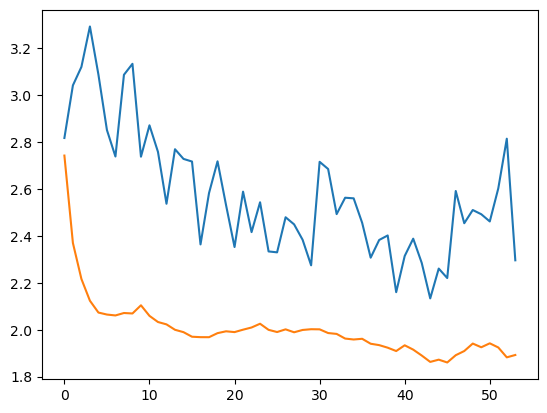

In [56]:
plt.plot(val_loss_history)
plt.plot(train_loss_history)
plt.show()

In [31]:
load_checkpoint(model, 'checkpoints/checkpoint_best.pth')

Loaded checkpoint from checkpoints/checkpoint_best.pth


/var/folders/92/b0fqb65132x3sm8hswbm4y9r0000gn/T/ipykernel_6672/3720291764.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_pa

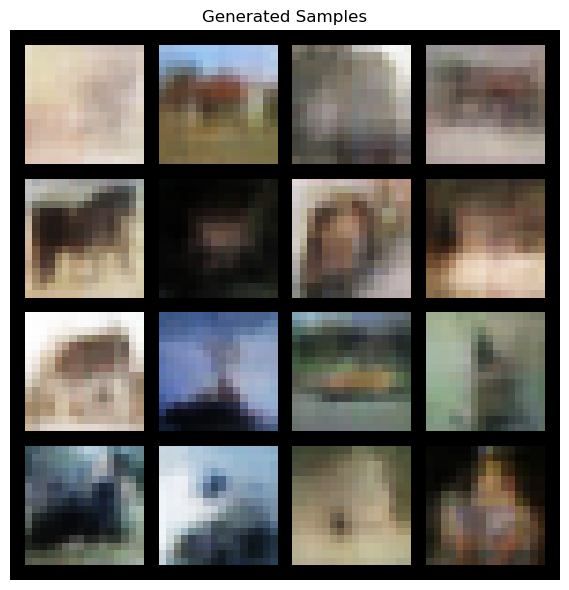

In [59]:
# Visualize generated samples
visualize_samples(model, n_samples=16, title="Generated Samples")
plt.show()

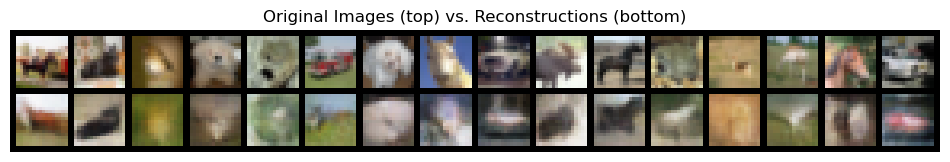

In [53]:
# Visualize reconstructions
visualize_reconstructions(model, test_dataset, n_images=16, device=device)

### Latent Space Interpolation

The following functions perform spherical linear interpolation (slerp) between latent codes.
This helps visualize the smoothness of the latent space.

In [54]:
def slerp(z0: torch.Tensor, z1: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    """
    Perform spherical linear interpolation (slerp) between two latent vectors.
    
    If the angle between vectors is very small, falls back to linear interpolation.
    
    Args:
        z0 (Tensor): Starting latent vector.
        z1 (Tensor): Ending latent vector.
        t (Tensor): Interpolation coefficient (scalar between 0 and 1).
        
    Returns:
        Tensor: Interpolated latent vector.
    """
    # Normalize the vectors
    z0_norm = z0 / (z0.norm(dim=-1, keepdim=True) + 1e-15)
    z1_norm = z1 / (z1.norm(dim=-1, keepdim=True) + 1e-15)
    # Compute the cosine of the angle between z0 and z1
    cos_omega = (z0_norm * z1_norm).sum(-1, keepdim=True)
    omega = torch.acos(torch.clamp(cos_omega, -1.0, 1.0))
    sin_omega = torch.sin(omega)
    # If the angle is very small, use linear interpolation
    near_zero = sin_omega < 1e-6
    factor0 = torch.where(near_zero, 1 - t, torch.sin((1 - t) * omega) / (sin_omega + 1e-15))
    factor1 = torch.where(near_zero, t, torch.sin(t * omega) / (sin_omega + 1e-15))
    return factor0 * z0 + factor1 * z1

def lerp(z0: torch.Tensor, z1: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    """
    Perform linear interpolation between two latent vectors.
    
    Args:
        z0 (Tensor): Starting latent vector.
        z1 (Tensor): Ending latent vector.
        t (Tensor): Interpolation coefficient.
    
    Returns:
        Tensor: Interpolated latent vector.
    """
    return (1 - t) * z0 + t * z1

def interpolate_latent(model: AlphaWGAN, img_batch: torch.Tensor, 
                       n_steps: int = 7,
                       num_images: int = 4,
                       method: str = "slerp", device: str = 'cpu') -> None:
    """
    Given a batch of images, encode them and perform interpolation in latent space.
    The user can select the interpolation method ('slerp' or 'lerp') and the number of images to use.
    Displays a grid of interpolated images.
    
    Args:
        model (AlphaWGAN): The trained model.
        img_batch (Tensor): A batch of images.
        n_steps (int): Number of interpolation steps.
        num_images (int): Number of images from the batch to use for interpolation.
        method (str): Interpolation method ("slerp" or "lerp").
        device (str): Device to use.
    """
    model.eval()
    with torch.no_grad():
        x = img_batch[:num_images].to(device)
        z = model.E(x)  # (num_images, latent_dim)
        t_vals = torch.linspace(0, 1, steps=n_steps, device=device)
        interpolated = []
        for i in range(z.size(0) - 1):
            z_start, z_end = z[i], z[i + 1]
            interp = torch.stack([slerp(z_start, z_end, t_val) if method == "slerp" 
                                    else lerp(z_start, z_end, t_val) for t_val in t_vals])
            interpolated.append(interp)
        z_interp = torch.cat(interpolated, dim=0)
        generated = model.G(z_interp)
    grid = make_grid(generated.cpu(), nrow=n_steps, normalize=True, range=(-1,1))
    plt.figure(figsize=(12, 8))
    plt.title(f"Latent Space Interpolation ({method.upper()})")
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.show()

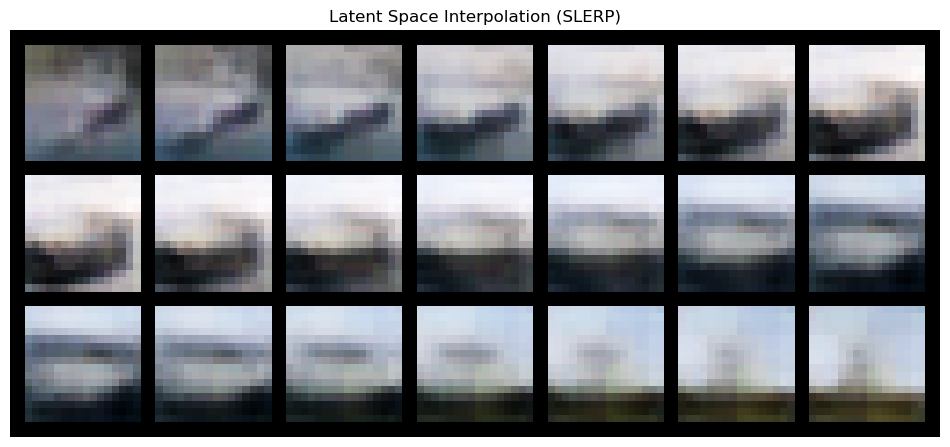

In [55]:
# Perform latent space interpolation on a batch from the test dataset
test_loader_iter = iter(test_loader)
img_batch, _ = next(test_loader_iter)
# You can choose the interpolation method: "slerp" (default) or "lerp"
interpolate_latent(model, img_batch, n_steps=7, num_images=4, method="slerp", device=device)